變數相關圖

Total variables used: 69


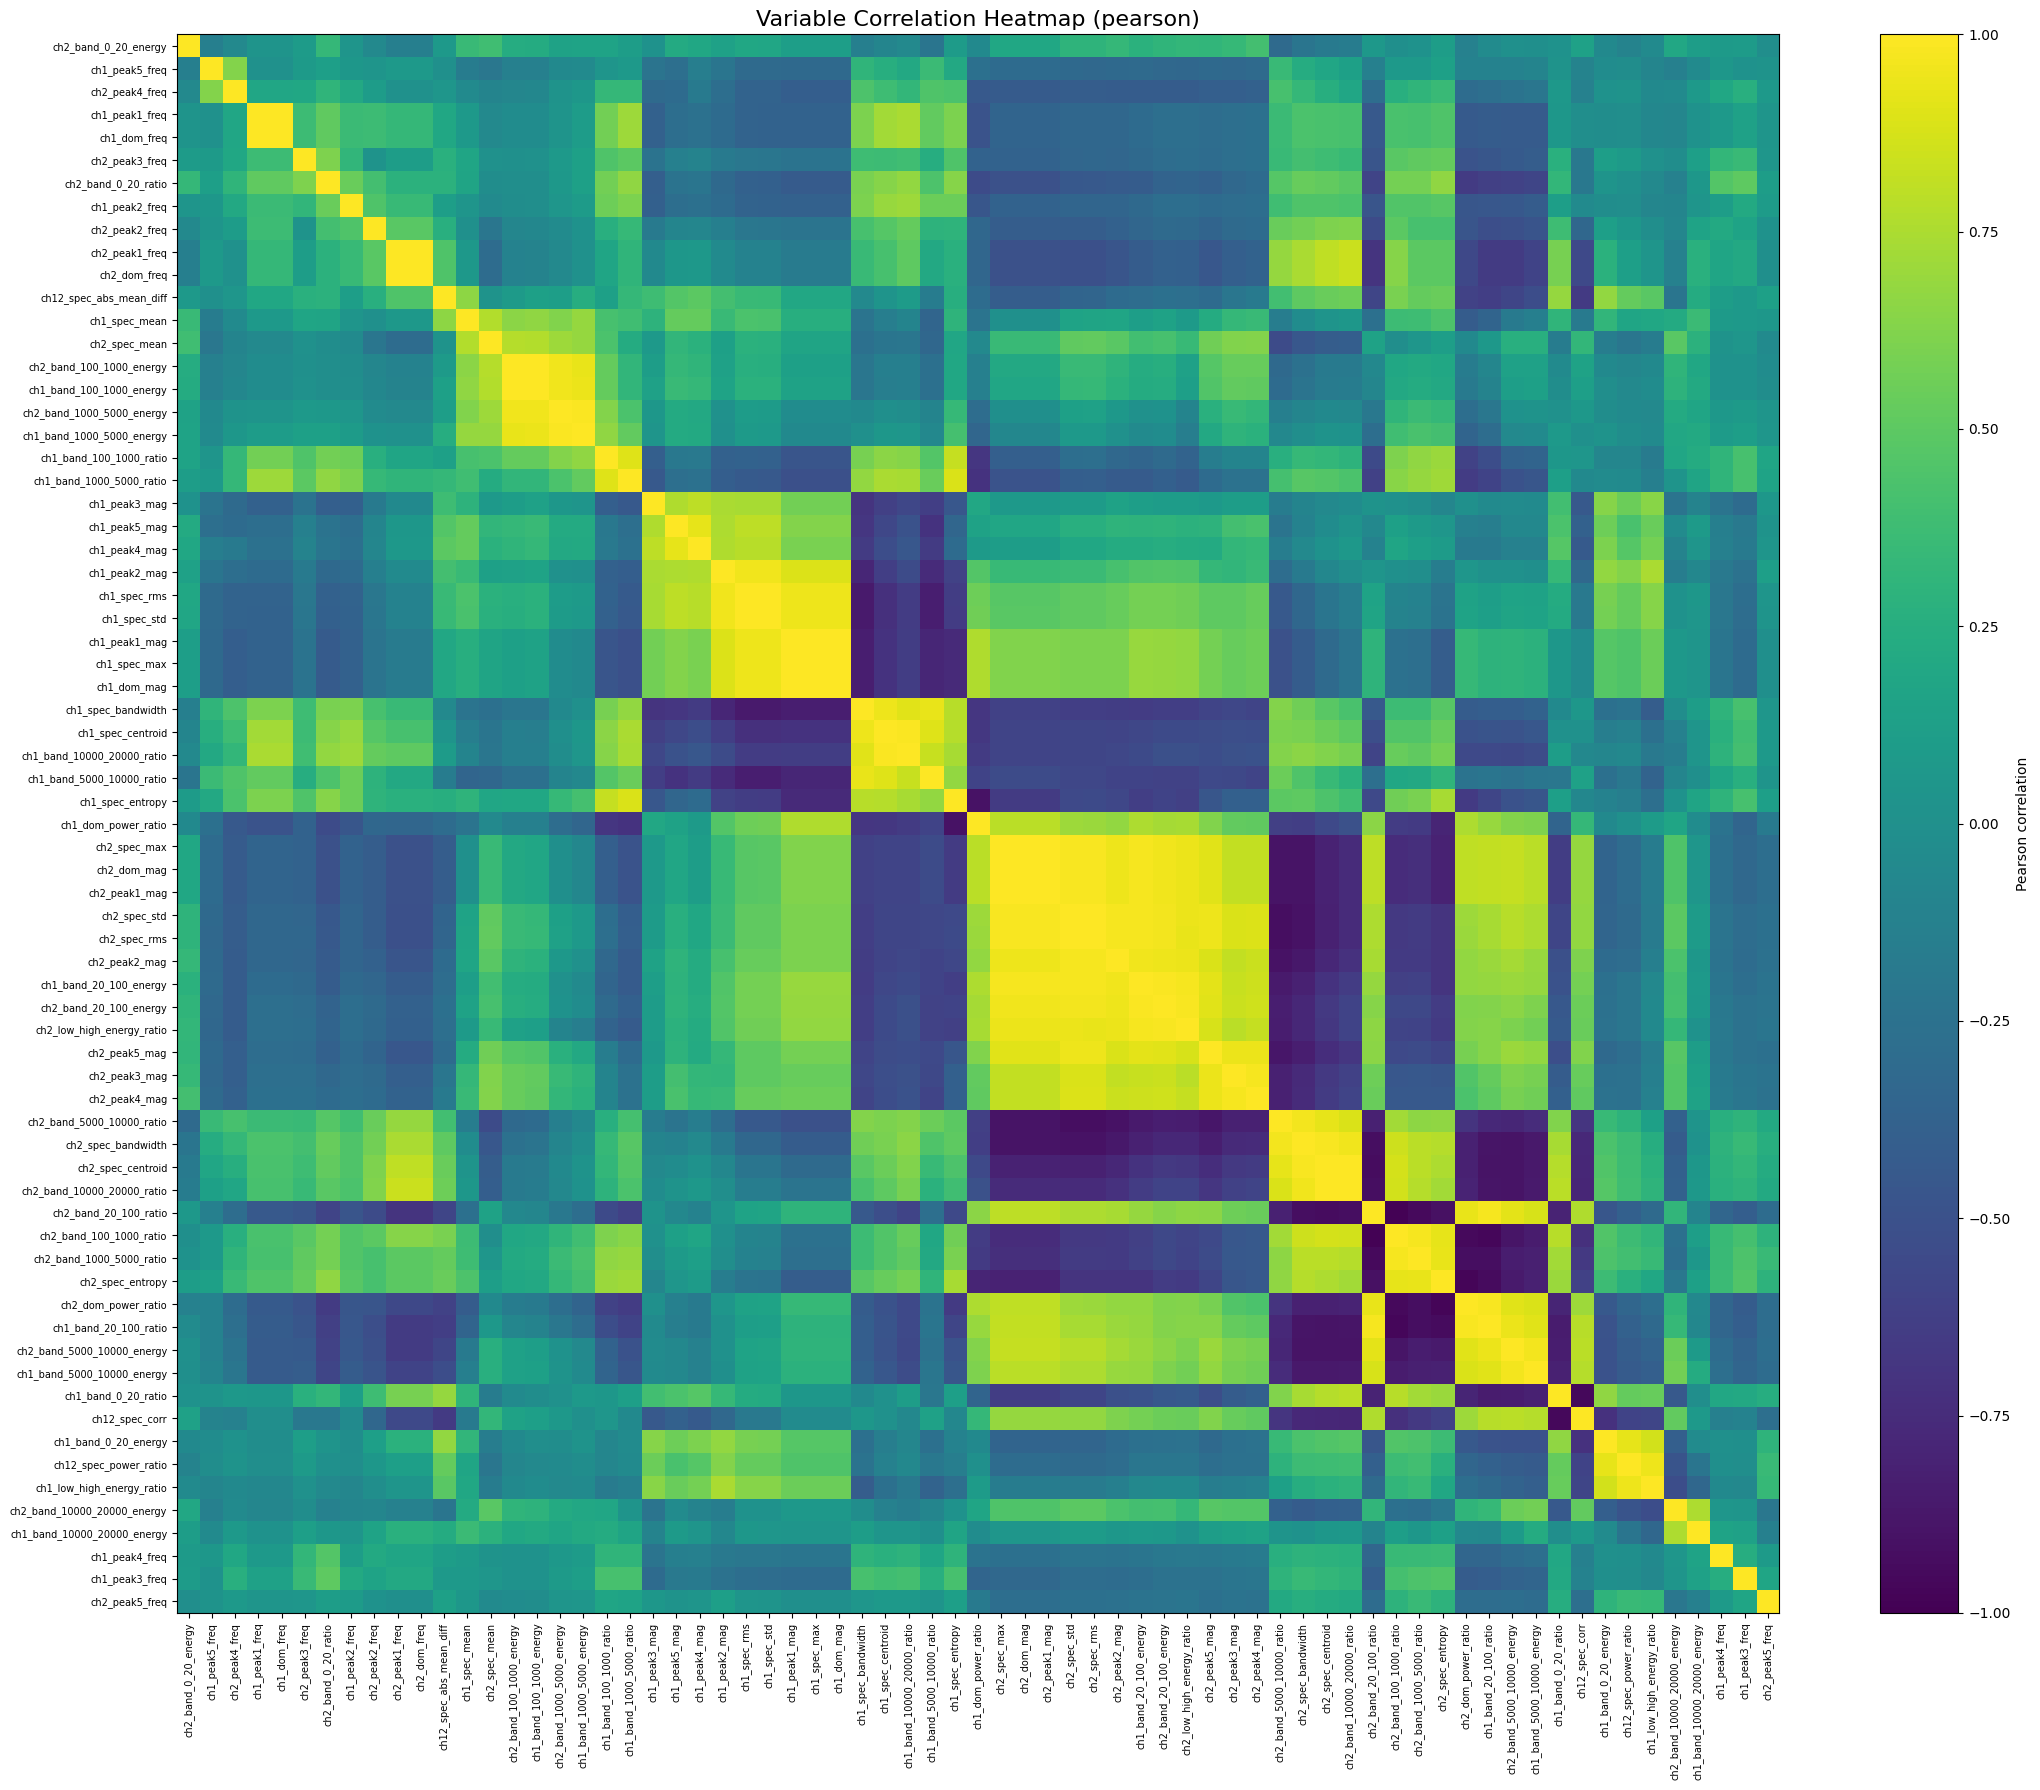


Done.
Saved correlation matrix CSV: correlation_plots/correlation_matrix_pearson.csv
Saved heatmap PNG: correlation_plots/correlation_heatmap_pearson.png
Saved top-pairs CSV: correlation_plots/top_correlation_pairs_pearson.csv

Top 20 correlated pairs:
                         var1                        var2      corr  abs_corr
0                 ch2_dom_mag               ch2_peak1_mag  1.000000  1.000000
1               ch1_peak1_mag                ch1_spec_max  1.000000  1.000000
2              ch1_peak1_freq                ch1_dom_freq  1.000000  1.000000
3               ch1_peak1_mag                 ch1_dom_mag  1.000000  1.000000
4              ch2_peak1_freq                ch2_dom_freq  1.000000  1.000000
5                ch2_spec_max               ch2_peak1_mag  1.000000  1.000000
6                ch2_spec_max                 ch2_dom_mag  1.000000  1.000000
7                ch1_spec_max                 ch1_dom_mag  1.000000  1.000000
8                ch2_spec_std               

In [25]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本設定
# =========================
INPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_DIR = "correlation_plots"

# 是否排除這些非分析欄位
EXCLUDE_COLS = [
    "row_index",
    "_id",
    "ch1_exists", "ch2_exists",
    "ch1_len_ok", "ch2_len_ok",
    "fs_ch1", "fs_ch2",
    "ch1_spec_len", "ch2_spec_len",
    "ch1_len_original", "ch2_len_original",
    "expected_len",
]

METHOD = "pearson"   # 可改 "spearman"
FIGSIZE = (22, 18)

# 顯示文字設定
SHOW_TICK_LABELS = True
TICK_FONTSIZE = 7

# 只畫上三角 / 下三角
MASK_UPPER_TRIANGLE = False

# 若想把高度相關的變數先排在一起，可改 True
SORT_BY_HIERARCHY_LIKE = True


# =========================
# 小工具
# =========================
def get_feature_columns(df, exclude_cols):
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    feature_cols = [c for c in numeric_df.columns if c not in exclude_cols]

    # 去掉常數欄位
    std_mask = numeric_df[feature_cols].std(axis=0, ddof=0) > 0
    feature_cols = [c for c in feature_cols if std_mask[c]]

    return feature_cols


def greedy_corr_order(corr_df):
    """
    不用 scipy，做一個簡單的 greedy 排序：
    讓彼此相關性高的變數盡量排在相鄰位置
    """
    cols = corr_df.columns.tolist()
    abs_corr = corr_df.abs().copy()

    # 找整體最相關的一對當起點
    np.fill_diagonal(abs_corr.values, -1.0)
    start_i, start_j = np.unravel_index(np.argmax(abs_corr.values), abs_corr.shape)

    ordered = [cols[start_i], cols[start_j]]
    remaining = [c for c in cols if c not in ordered]

    while remaining:
        best_col = None
        best_score = -np.inf

        for c in remaining:
            # 和目前序列兩端的平均相關度
            score_left = abs_corr.loc[c, ordered[0]]
            score_right = abs_corr.loc[c, ordered[-1]]

            if score_left >= score_right:
                score = score_left
                side = "left"
            else:
                score = score_right
                side = "right"

            if score > best_score:
                best_score = score
                best_col = (c, side)

        c, side = best_col
        if side == "left":
            ordered = [c] + ordered
        else:
            ordered = ordered + [c]

        remaining.remove(c)

    return ordered


# =========================
# 主程式
# =========================
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # 讀資料
    df = pd.read_csv(INPUT_CSV)

    # 取數值欄位
    feature_cols = get_feature_columns(df, EXCLUDE_COLS)
    X = df[feature_cols].copy()

    print(f"Total variables used: {len(feature_cols)}")

    # 計算相關矩陣
    corr_df = X.corr(method=METHOD)

    # 排序
    if SORT_BY_HIERARCHY_LIKE:
        order = greedy_corr_order(corr_df)
        corr_df = corr_df.loc[order, order]

    # 存 CSV
    corr_csv_path = os.path.join(OUTPUT_DIR, f"correlation_matrix_{METHOD}.csv")
    corr_df.to_csv(corr_csv_path, encoding="utf-8-sig")

    # 畫 heatmap
    fig, ax = plt.subplots(figsize=FIGSIZE)

    corr_values = corr_df.values.copy()

    if MASK_UPPER_TRIANGLE:
        mask = np.triu(np.ones_like(corr_values, dtype=bool), k=1)
        corr_values = np.ma.masked_where(mask, corr_values)

    im = ax.imshow(
        corr_values,
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f"{METHOD.capitalize()} correlation", rotation=90)

    ax.set_title(f"Variable Correlation Heatmap ({METHOD})", fontsize=16)

    if SHOW_TICK_LABELS:
        ax.set_xticks(np.arange(len(corr_df.columns)))
        ax.set_yticks(np.arange(len(corr_df.index)))
        ax.set_xticklabels(corr_df.columns, rotation=90, fontsize=TICK_FONTSIZE)
        ax.set_yticklabels(corr_df.index, fontsize=TICK_FONTSIZE)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.tight_layout()

    heatmap_path = os.path.join(OUTPUT_DIR, f"correlation_heatmap_{METHOD}.png")
    fig.savefig(heatmap_path, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # 額外輸出：只列出高相關 pair
    abs_corr = corr_df.abs().copy()
    pairs = []

    cols = corr_df.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            pairs.append({
                "var1": cols[i],
                "var2": cols[j],
                "corr": corr_df.iloc[i, j],
                "abs_corr": abs_corr.iloc[i, j],
            })

    pairs_df = pd.DataFrame(pairs).sort_values("abs_corr", ascending=False).reset_index(drop=True)
    pairs_csv_path = os.path.join(OUTPUT_DIR, f"top_correlation_pairs_{METHOD}.csv")
    pairs_df.to_csv(pairs_csv_path, index=False, encoding="utf-8-sig")

    print("\nDone.")
    print(f"Saved correlation matrix CSV: {corr_csv_path}")
    print(f"Saved heatmap PNG: {heatmap_path}")
    print(f"Saved top-pairs CSV: {pairs_csv_path}")
    print("\nTop 20 correlated pairs:")
    print(pairs_df.head(20))


if __name__ == "__main__":
    main()

Total variables used: 69


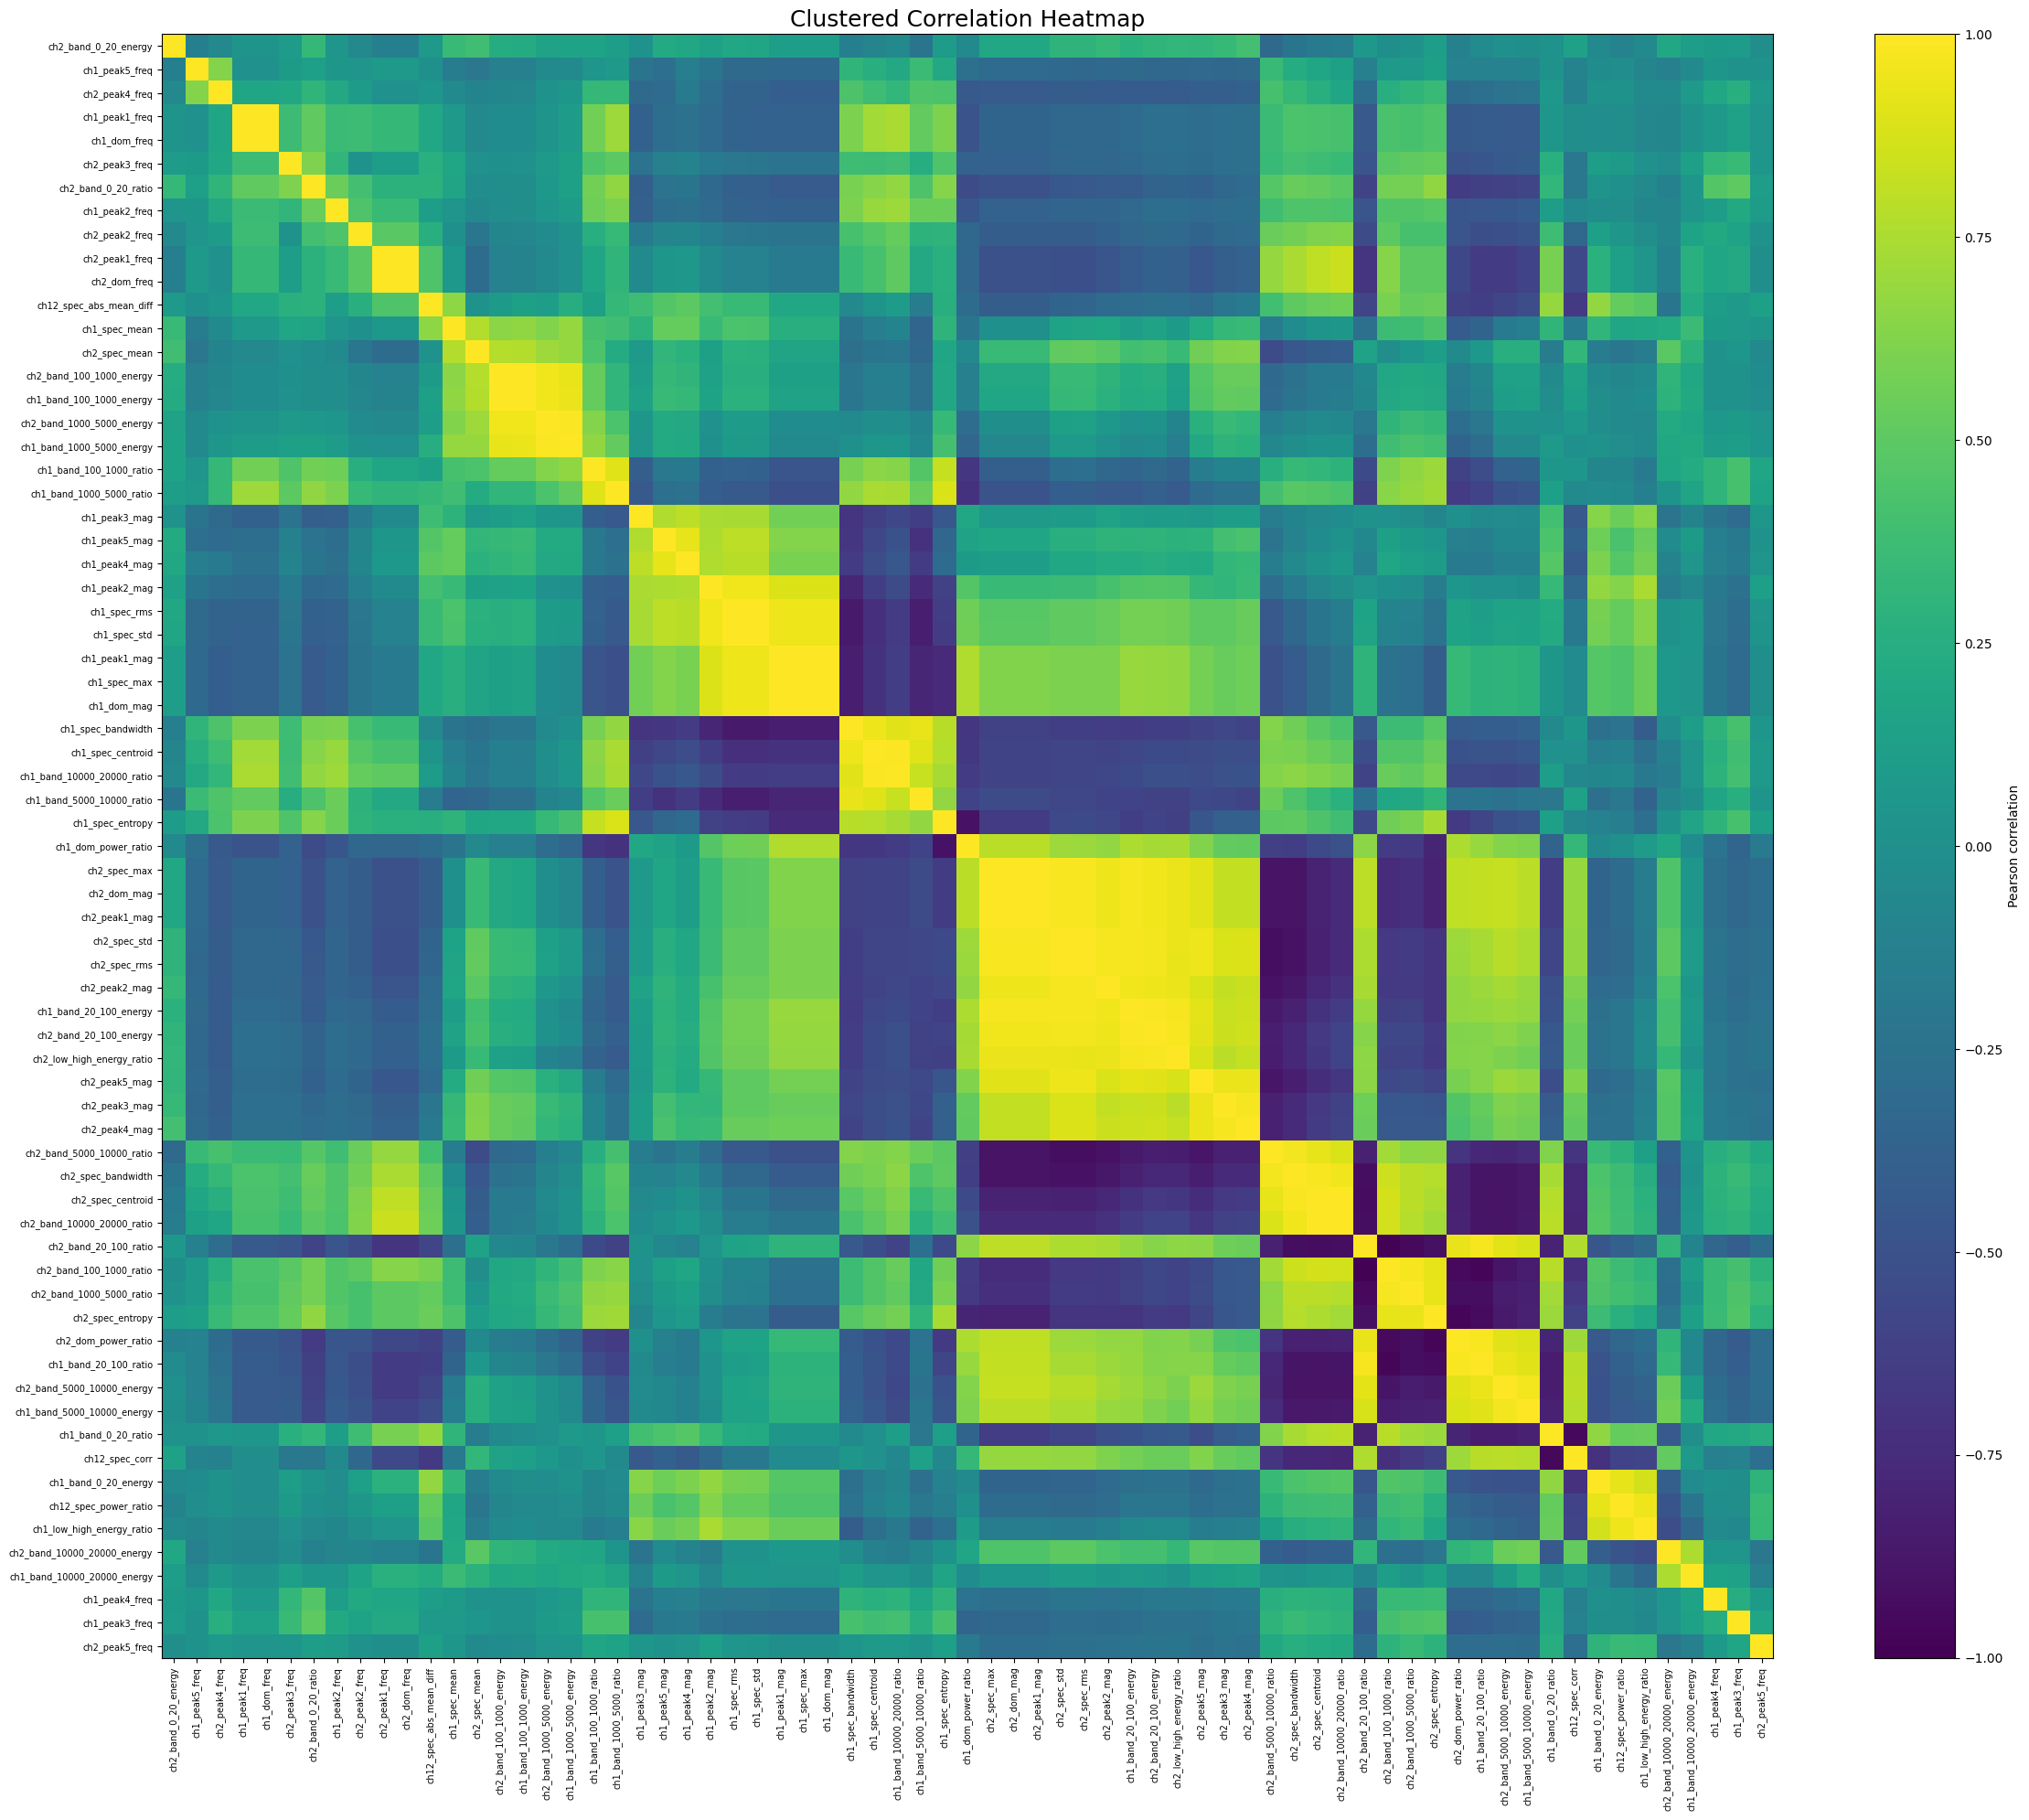


Done.
Saved sorted heatmap: correlation_clustered/correlation_heatmap_clustered_pearson.png
Saved sorted matrix: correlation_clustered/correlation_matrix_sorted_pearson.csv
Saved variable order: correlation_clustered/sorted_variable_order.csv


In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 基本設定
# =========================
INPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_DIR = "correlation_clustered"

EXCLUDE_COLS = [
    "row_index",
    "_id",
    "ch1_exists", "ch2_exists",
    "ch1_len_ok", "ch2_len_ok",
    "fs_ch1", "fs_ch2",
    "ch1_spec_len", "ch2_spec_len",
    "ch1_len_original", "ch2_len_original",
    "expected_len",
]

METHOD = "pearson"   # 可改成 "spearman"
FIGSIZE = (24, 20)
TICK_FONTSIZE = 7
SHOW_TICK_LABELS = True

# 若你只想看正相關群聚，可改 True
USE_ABS_CORR_FOR_ORDER = True


# =========================
# 小工具
# =========================
def get_feature_columns(df, exclude_cols):
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    feature_cols = [c for c in numeric_df.columns if c not in exclude_cols]

    # 去掉常數欄位
    std_mask = numeric_df[feature_cols].std(axis=0, ddof=0) > 0
    feature_cols = [c for c in feature_cols if std_mask[c]]

    return feature_cols


def greedy_cluster_order(corr_df, use_abs=True):
    """
    不用 scipy，做一個簡單的貪婪排序：
    讓越相關的變數盡量排在相鄰位置，
    這樣 heatmap 上顏色會比較成塊。
    """
    cols = corr_df.columns.tolist()

    if use_abs:
        score_df = corr_df.abs().copy()
    else:
        score_df = corr_df.copy()

    # 避免自己跟自己最大
    score = score_df.values.copy()
    np.fill_diagonal(score, -np.inf)

    # 找最相關的一對當起點
    i0, j0 = np.unravel_index(np.argmax(score), score.shape)
    ordered = [cols[i0], cols[j0]]
    remaining = [c for c in cols if c not in ordered]

    while remaining:
        best_c = None
        best_side = None
        best_score = -np.inf

        left = ordered[0]
        right = ordered[-1]

        for c in remaining:
            s_left = score_df.loc[c, left]
            s_right = score_df.loc[c, right]

            if s_left > best_score:
                best_score = s_left
                best_c = c
                best_side = "left"

            if s_right > best_score:
                best_score = s_right
                best_c = c
                best_side = "right"

        if best_side == "left":
            ordered = [best_c] + ordered
        else:
            ordered = ordered + [best_c]

        remaining.remove(best_c)

    return ordered


# =========================
# 主程式
# =========================
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # 讀資料
    df = pd.read_csv(INPUT_CSV)

    # 取數值變數
    feature_cols = get_feature_columns(df, EXCLUDE_COLS)
    X = df[feature_cols].copy()

    print(f"Total variables used: {len(feature_cols)}")

    # 相關矩陣
    corr_df = X.corr(method=METHOD)

    # 重新排序：讓相關的排在一起
    ordered_cols = greedy_cluster_order(corr_df, use_abs=USE_ABS_CORR_FOR_ORDER)
    corr_sorted = corr_df.loc[ordered_cols, ordered_cols]

    # 存排序後矩陣
    corr_csv = os.path.join(OUTPUT_DIR, f"correlation_matrix_sorted_{METHOD}.csv")
    corr_sorted.to_csv(corr_csv, encoding="utf-8-sig")

    order_csv = os.path.join(OUTPUT_DIR, "sorted_variable_order.csv")
    pd.DataFrame({"variable": ordered_cols}).to_csv(order_csv, index=False, encoding="utf-8-sig")

    # 畫 heatmap
    fig, ax = plt.subplots(figsize=FIGSIZE)

    im = ax.imshow(
        corr_sorted.values,
        vmin=-1,
        vmax=1,
        aspect="auto"
    )

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f"{METHOD.capitalize()} correlation", rotation=90)

    ax.set_title("Clustered Correlation Heatmap", fontsize=18)

    if SHOW_TICK_LABELS:
        ax.set_xticks(np.arange(len(ordered_cols)))
        ax.set_yticks(np.arange(len(ordered_cols)))
        ax.set_xticklabels(ordered_cols, rotation=90, fontsize=TICK_FONTSIZE)
        ax.set_yticklabels(ordered_cols, fontsize=TICK_FONTSIZE)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.tight_layout()

    heatmap_png = os.path.join(OUTPUT_DIR, f"correlation_heatmap_clustered_{METHOD}.png")
    fig.savefig(heatmap_png, dpi=220, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print("\nDone.")
    print(f"Saved sorted heatmap: {heatmap_png}")
    print(f"Saved sorted matrix: {corr_csv}")
    print(f"Saved variable order: {order_csv}")


if __name__ == "__main__":
    main()

4. DWT分析

In [34]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

# =========================
# 基本設定
# =========================
INPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_DIR = "all_variables_A_D_relationship"

WAVELET = "db4"
LEVEL = 3
USE_ZSCORE_BEFORE_DWT = True

EXCLUDE_COLS = [
    "row_index",
    "_id",
    "ch1_exists", "ch2_exists",
    "ch1_len_ok", "ch2_len_ok",
    "fs_ch1", "fs_ch2",
    "ch1_spec_len", "ch2_spec_len",
    "ch1_len_original", "ch2_len_original",
    "expected_len",
]


# =========================
# 小工具
# =========================
def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    m = np.mean(x)
    s = np.std(x, ddof=0)
    if s < 1e-12:
        return np.zeros_like(x)
    return (x - m) / s


def safe_inverse_waverec(coeffs, wavelet, target_len):
    rec = pywt.waverec(coeffs, wavelet=wavelet)
    rec = np.asarray(rec, dtype=float)

    if len(rec) > target_len:
        rec = rec[:target_len]
    elif len(rec) < target_len:
        rec = np.pad(rec, (0, target_len - len(rec)), mode="constant")

    return rec


def reconstruct_component(coeffs, wavelet, keep_parts, original_len):
    """
    coeffs = [cA_n, cD_n, cD_(n-1), ..., cD1]
    keep_parts: {"A", "D1", "D2", "D3", ...}
    """
    n_level = len(coeffs) - 1
    new_coeffs = []

    # A
    if "A" in keep_parts:
        new_coeffs.append(coeffs[0].copy())
    else:
        new_coeffs.append(np.zeros_like(coeffs[0]))

    # Dn ... D1
    for idx, arr in enumerate(coeffs[1:], start=1):
        level_num = n_level - idx + 1
        key = f"D{level_num}"

        if key in keep_parts:
            new_coeffs.append(arr.copy())
        else:
            new_coeffs.append(np.zeros_like(arr))

    return safe_inverse_waverec(new_coeffs, wavelet, original_len)


def get_A_D_reconstructions(x, wavelet="db4", level=3):
    max_level = pywt.dwt_max_level(
        data_len=len(x),
        filter_len=pywt.Wavelet(wavelet).dec_len
    )
    use_level = min(level, max_level)

    coeffs = pywt.wavedec(x, wavelet=wavelet, level=use_level)

    A = reconstruct_component(coeffs, wavelet, {"A"}, len(x))
    D1 = reconstruct_component(coeffs, wavelet, {"D1"}, len(x))
    D2 = reconstruct_component(coeffs, wavelet, {"D2"}, len(x))
    D3 = reconstruct_component(coeffs, wavelet, {"D3"}, len(x))

    return A, D1, D2, D3, use_level


def corr_safe(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan

    return float(np.corrcoef(a, b)[0, 1])


def get_feature_columns(df, exclude_cols):
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    feature_cols = [c for c in numeric_df.columns if c not in exclude_cols]

    # 去掉常數欄位
    std_mask = numeric_df[feature_cols].std(axis=0, ddof=0) > 0
    feature_cols = [c for c in feature_cols if std_mask[c]]

    return feature_cols


# =========================
# 主程式
# =========================
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    df = pd.read_csv(INPUT_CSV)

    feature_cols = get_feature_columns(df, EXCLUDE_COLS)
    print(f"Total variables to process: {len(feature_cols)}")

    summary_rows = []

    for i, feature in enumerate(feature_cols, start=1):
        x = df[feature].astype(float).values

        if USE_ZSCORE_BEFORE_DWT:
            x_proc = zscore_1d(x)
        else:
            x_proc = x.copy()

        A, D1, D2, D3, level_used = get_A_D_reconstructions(
            x_proc,
            wavelet=WAVELET,
            level=LEVEL
        )

        row = {
            "feature": feature,
            "wavelet": WAVELET,
            "level_used": level_used,
            "corr_A_D1": corr_safe(A, D1),
            "corr_A_D2": corr_safe(A, D2),
            "corr_A_D3": corr_safe(A, D3),
            "corr_D1_D2": corr_safe(D1, D2),
            "corr_D1_D3": corr_safe(D1, D3),
            "corr_D2_D3": corr_safe(D2, D3),
        }
        summary_rows.append(row)

        # 畫圖
        fig, axes = plt.subplots(4, 2, figsize=(16, 12))
        x_axis = np.arange(len(x_proc))

        # Original
        axes[0, 0].plot(x_axis, x_proc, linewidth=1.0)
        axes[0, 0].set_title("Original")
        axes[0, 0].grid(True, alpha=0.3)

        # A only
        axes[0, 1].plot(x_axis, A, linewidth=1.0)
        axes[0, 1].set_title("A only")
        axes[0, 1].grid(True, alpha=0.3)

        # D1
        axes[1, 0].plot(x_axis, D1, linewidth=1.0)
        axes[1, 0].set_title("D1 only")
        axes[1, 0].grid(True, alpha=0.3)

        # D2
        axes[1, 1].plot(x_axis, D2, linewidth=1.0)
        axes[1, 1].set_title("D2 only")
        axes[1, 1].grid(True, alpha=0.3)

        # D3
        axes[2, 0].plot(x_axis, D3, linewidth=1.0)
        axes[2, 0].set_title("D3 only")
        axes[2, 0].grid(True, alpha=0.3)

        # A vs D1
        axes[2, 1].scatter(A, D1, s=8, alpha=0.5)
        axes[2, 1].set_title(f"A vs D1 | corr={row['corr_A_D1']:.3f}")
        axes[2, 1].set_xlabel("A")
        axes[2, 1].set_ylabel("D1")
        axes[2, 1].grid(True, alpha=0.3)

        # A vs D2
        axes[3, 0].scatter(A, D2, s=8, alpha=0.5)
        axes[3, 0].set_title(f"A vs D2 | corr={row['corr_A_D2']:.3f}")
        axes[3, 0].set_xlabel("A")
        axes[3, 0].set_ylabel("D2")
        axes[3, 0].grid(True, alpha=0.3)

        # D1 vs D2
        axes[3, 1].scatter(D1, D2, s=8, alpha=0.5)
        axes[3, 1].set_title(f"D1 vs D2 | corr={row['corr_D1_D2']:.3f}")
        axes[3, 1].set_xlabel("D1")
        axes[3, 1].set_ylabel("D2")
        axes[3, 1].grid(True, alpha=0.3)

        fig.suptitle(
            f"{feature} | wavelet={WAVELET}, level_used={level_used}",
            fontsize=16
        )
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        out_png = os.path.join(OUTPUT_DIR, f"{feature}_A_D_relationship.png")
        fig.savefig(out_png, dpi=180, bbox_inches="tight")
        plt.close(fig)

        if i % 10 == 0 or i == len(feature_cols):
            print(f"Processed {i}/{len(feature_cols)}")

    # 存 summary
    summary_df = pd.DataFrame(summary_rows)
    summary_csv = os.path.join(OUTPUT_DIR, "A_D_relationship_summary.csv")
    summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")

    print("\nDone.")
    print(f"Saved all figures to: {OUTPUT_DIR}")
    print(f"Saved summary CSV: {summary_csv}")
    print(summary_df.head(20))


if __name__ == "__main__":
    main()

Total variables to process: 69
Processed 10/69
Processed 20/69
Processed 30/69
Processed 40/69
Processed 50/69
Processed 60/69
Processed 69/69

Done.
Saved all figures to: all_variables_A_D_relationship
Saved summary CSV: all_variables_A_D_relationship/A_D_relationship_summary.csv
                       feature wavelet  level_used  corr_A_D1  corr_A_D2  \
0                ch1_spec_mean     db4           3   0.000263  -0.000161   
1                 ch1_spec_std     db4           3  -0.000074   0.001600   
2                 ch1_spec_max     db4           3  -0.000248   0.001507   
3                 ch1_spec_rms     db4           3  -0.000070   0.001596   
4                 ch1_dom_freq     db4           3   0.000005   0.015245   
5                  ch1_dom_mag     db4           3  -0.000248   0.001507   
6          ch1_dom_power_ratio     db4           3  -0.000488   0.001966   
7            ch1_spec_centroid     db4           3   0.000228   0.008640   
8           ch1_spec_bandwidth    

加一些輔助線

In [35]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

# =========================================================
# 基本設定
# =========================================================
INPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_DIR = "all69_wavelet_guided_and_cycle_level"

WAVELET = "db4"
LEVEL = 3
USE_ZSCORE_BEFORE_DWT = True

# 用來切 cycle 的 anchor
ANCHOR_FEATURE = "ch2_dom_power_ratio"
ANCHOR_SMOOTH_WINDOW = 9
MIN_DISTANCE = 70          # 相鄰 cycle 最少距離，需依資料調整
USE_MINIMA_FOR_CYCLE = True

# 輔助線設定
WINDOW_ORIGINAL = 81
WINDOW_A = 81
WINDOW_D = 81

# 排除非分析欄位
EXCLUDE_COLS = [
    "row_index",
    "_id",
    "ch1_exists", "ch2_exists",
    "ch1_len_ok", "ch2_len_ok",
    "fs_ch1", "fs_ch2",
    "ch1_spec_len", "ch2_spec_len",
    "ch1_len_original", "ch2_len_original",
    "expected_len",
]

SAVE_PER_VARIABLE_GUIDED_FIG = True
SAVE_PER_VARIABLE_CYCLE_FIG = True
SAVE_SUMMARY_CSV = True

# =========================================================
# 小工具
# =========================================================
def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    m = np.mean(x)
    s = np.std(x, ddof=0)
    if s < 1e-12:
        return np.zeros_like(x)
    return (x - m) / s


def moving_average(x, w):
    return pd.Series(x).rolling(w, center=True, min_periods=1).mean().values


def safe_slope(y):
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y), dtype=float)
    mask = np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan
    coef = np.polyfit(x[mask], y[mask], 1)
    return float(coef[0])


def get_feature_columns(df, exclude_cols):
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    feature_cols = [c for c in numeric_df.columns if c not in exclude_cols]

    std_mask = numeric_df[feature_cols].std(axis=0, ddof=0) > 0
    feature_cols = [c for c in feature_cols if std_mask[c]]

    return feature_cols


def safe_inverse_waverec(coeffs, wavelet, target_len):
    rec = pywt.waverec(coeffs, wavelet=wavelet)
    rec = np.asarray(rec, dtype=float)

    if len(rec) > target_len:
        rec = rec[:target_len]
    elif len(rec) < target_len:
        rec = np.pad(rec, (0, target_len - len(rec)), mode="constant")

    return rec


def reconstruct_component(coeffs, wavelet, keep_parts, original_len):
    """
    coeffs = [cA_n, cD_n, cD_(n-1), ..., cD1]
    keep_parts: {"A", "D1", "D2", "D3", ...}
    """
    n_level = len(coeffs) - 1
    new_coeffs = []

    # A
    if "A" in keep_parts:
        new_coeffs.append(coeffs[0].copy())
    else:
        new_coeffs.append(np.zeros_like(coeffs[0]))

    # Dn ... D1
    for idx, arr in enumerate(coeffs[1:], start=1):
        level_num = n_level - idx + 1
        key = f"D{level_num}"
        if key in keep_parts:
            new_coeffs.append(arr.copy())
        else:
            new_coeffs.append(np.zeros_like(arr))

    return safe_inverse_waverec(new_coeffs, wavelet, original_len)


def get_A_D_reconstructions(x, wavelet="db4", level=3):
    max_level = pywt.dwt_max_level(
        data_len=len(x),
        filter_len=pywt.Wavelet(wavelet).dec_len
    )
    use_level = min(level, max_level)

    coeffs = pywt.wavedec(x, wavelet=wavelet, level=use_level)

    A = reconstruct_component(coeffs, wavelet, {"A"}, len(x))
    D1 = reconstruct_component(coeffs, wavelet, {"D1"}, len(x))
    D2 = reconstruct_component(coeffs, wavelet, {"D2"}, len(x))

    return A, D1, D2, use_level


def local_extrema_indices(x, min_distance=50, mode="min"):
    """
    mode = "min" or "max"
    不依賴 scipy 的簡單局部極值偵測
    """
    x = np.asarray(x, dtype=float)
    idxs = []

    for i in range(1, len(x) - 1):
        if mode == "min":
            cond = (x[i] <= x[i - 1]) and (x[i] < x[i + 1])
        else:
            cond = (x[i] >= x[i - 1]) and (x[i] > x[i + 1])

        if cond:
            idxs.append(i)

    if len(idxs) == 0:
        return []

    selected = [idxs[0]]
    for idx in idxs[1:]:
        if idx - selected[-1] >= min_distance:
            selected.append(idx)
        else:
            prev = selected[-1]
            if mode == "min":
                if x[idx] < x[prev]:
                    selected[-1] = idx
            else:
                if x[idx] > x[prev]:
                    selected[-1] = idx

    return selected


def build_cycle_boundaries(anchor_signal, smooth_window=9, min_distance=70, use_minima=True):
    anchor_smooth = moving_average(anchor_signal, smooth_window)
    mode = "min" if use_minima else "max"
    boundaries = local_extrema_indices(anchor_smooth, min_distance=min_distance, mode=mode)

    if len(boundaries) < 3:
        raise ValueError(
            f"找到的 cycle 邊界太少: {len(boundaries)}。請調整 MIN_DISTANCE / ANCHOR_SMOOTH_WINDOW。"
        )

    if boundaries[0] != 0:
        boundaries = [0] + boundaries
    if boundaries[-1] != len(anchor_signal):
        boundaries = boundaries + [len(anchor_signal)]

    return boundaries, anchor_smooth


def calc_cycle_stats(signal, boundaries):
    rows = []
    for i in range(len(boundaries) - 1):
        s = boundaries[i]
        e = boundaries[i + 1]
        seg = np.asarray(signal[s:e], dtype=float)

        if len(seg) < 2:
            continue

        rows.append({
            "cycle_id": i,
            "start": s,
            "end": e - 1,
            "length": len(seg),
            "mean": float(np.mean(seg)),
            "max": float(np.max(seg)),
            "min": float(np.min(seg)),
            "amplitude": float(np.max(seg) - np.min(seg)),
            "rms": float(np.sqrt(np.mean(seg ** 2))),
            "energy": float(np.sum(seg ** 2)),
            "mean_abs": float(np.mean(np.abs(seg))),
            "max_abs": float(np.max(np.abs(seg))),
        })

    return pd.DataFrame(rows)


def add_trend_line(ax, y, label_prefix="trend"):
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y), dtype=float)
    mask = np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan
    coef = np.polyfit(x[mask], y[mask], 1)
    trend = np.polyval(coef, x)
    ax.plot(x, trend, linewidth=2.0, label=f"{label_prefix}, slope={coef[0]:.4f}")
    return float(coef[0])


# =========================================================
# 圖：每個變數的 guided 圖
# =========================================================
def plot_guided_wavelet_figure(feature, x_proc, A, D1, D2, boundaries, save_path):
    x_axis = np.arange(len(x_proc))

    # Original 的 envelope
    s0 = pd.Series(x_proc)
    orig_max = s0.rolling(WINDOW_ORIGINAL, center=True, min_periods=1).max()
    orig_min = s0.rolling(WINDOW_ORIGINAL, center=True, min_periods=1).min()
    orig_mid = (orig_max + orig_min) / 2.0

    # A 的慢變
    A_mean = pd.Series(A).rolling(WINDOW_A, center=True, min_periods=1).mean()

    # D1 / D2 的強度
    d1_strength = pd.Series(np.abs(D1)).rolling(WINDOW_D, center=True, min_periods=1).mean()
    d2_strength = pd.Series(np.abs(D2)).rolling(WINDOW_D, center=True, min_periods=1).mean()

    fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

    # Original
    axes[0].plot(x_axis, x_proc, linewidth=0.9, label="Original")
    axes[0].plot(x_axis, orig_max, linewidth=1.2, label="rolling max")
    axes[0].plot(x_axis, orig_min, linewidth=1.2, label="rolling min")
    axes[0].plot(x_axis, orig_mid, linewidth=1.5, label="envelope center")
    for b in boundaries:
        axes[0].axvline(b, alpha=0.15)
    axes[0].set_title("Original + envelope guides")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # A
    axes[1].plot(x_axis, A, linewidth=0.9, label="A only")
    axes[1].plot(x_axis, A_mean, linewidth=1.5, label="rolling mean(A)")
    add_trend_line(axes[1], A_mean.values, label_prefix="trend(A_mean)")
    for b in boundaries:
        axes[1].axvline(b, alpha=0.15)
    axes[1].set_title("A only + rolling mean / trend")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # D1
    axes[2].plot(x_axis, D1, linewidth=0.8, label="D1 only")
    axes[2].plot(x_axis, d1_strength, linewidth=1.6, label="rolling mean(abs(D1))")
    add_trend_line(axes[2], d1_strength.values, label_prefix="trend(D1_strength)")
    for b in boundaries:
        axes[2].axvline(b, alpha=0.15)
    axes[2].set_title("D1 only + strength guide")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    # D2
    axes[3].plot(x_axis, D2, linewidth=0.8, label="D2 only")
    axes[3].plot(x_axis, d2_strength, linewidth=1.6, label="rolling mean(abs(D2))")
    add_trend_line(axes[3], d2_strength.values, label_prefix="trend(D2_strength)")
    for b in boundaries:
        axes[3].axvline(b, alpha=0.15)
    axes[3].set_title("D2 only + strength guide")
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    axes[-1].set_xlabel("time index")
    fig.suptitle(f"{feature} | guided Original / A / D1 / D2", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close(fig)


# =========================================================
# 圖：每個變數的 cycle-level 指標圖
# =========================================================
def plot_cycle_level_figure(feature, x_proc, A, D1, D2, boundaries, save_path):
    orig_cycle = calc_cycle_stats(x_proc, boundaries)
    A_cycle = calc_cycle_stats(A, boundaries)
    D1_cycle = calc_cycle_stats(np.abs(D1), boundaries)
    D2_cycle = calc_cycle_stats(np.abs(D2), boundaries)

    # 只保留 cycle id 對齊後最短長度
    n = min(len(orig_cycle), len(A_cycle), len(D1_cycle), len(D2_cycle))
    orig_cycle = orig_cycle.iloc[:n].copy()
    A_cycle = A_cycle.iloc[:n].copy()
    D1_cycle = D1_cycle.iloc[:n].copy()
    D2_cycle = D2_cycle.iloc[:n].copy()

    cycle_id = orig_cycle["cycle_id"].values

    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

    # Original amplitude
    axes[0].plot(cycle_id, orig_cycle["amplitude"], marker="o", linewidth=1.3, label="Original cycle amplitude")
    add_trend_line(axes[0], orig_cycle["amplitude"].values, label_prefix="trend")
    axes[0].set_title("Cycle-level: Original amplitude")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # A mean
    axes[1].plot(cycle_id, A_cycle["mean"], marker="o", linewidth=1.3, label="A cycle mean")
    add_trend_line(axes[1], A_cycle["mean"].values, label_prefix="trend")
    axes[1].set_title("Cycle-level: A mean")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # D1 strength
    axes[2].plot(cycle_id, D1_cycle["mean_abs"], marker="o", linewidth=1.3, label="mean(abs(D1)) per cycle")
    axes[2].plot(cycle_id, D1_cycle["max_abs"], marker="o", linewidth=1.0, label="max(abs(D1)) per cycle")
    add_trend_line(axes[2], D1_cycle["mean_abs"].values, label_prefix="trend(mean_abs_D1)")
    axes[2].set_title("Cycle-level: D1 strength")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    # D2 strength
    axes[3].plot(cycle_id, D2_cycle["mean_abs"], marker="o", linewidth=1.3, label="mean(abs(D2)) per cycle")
    axes[3].plot(cycle_id, D2_cycle["energy"], marker="o", linewidth=1.0, label="energy(abs(D2)) per cycle")
    add_trend_line(axes[3], D2_cycle["mean_abs"].values, label_prefix="trend(mean_abs_D2)")
    axes[3].set_title("Cycle-level: D2 strength")
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    axes[-1].set_xlabel("cycle id")
    fig.suptitle(f"{feature} | cycle-level indicators", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    # 回傳 summary 用
    row = {
        "feature": feature,
        "n_cycles": n,

        "orig_amp_slope": safe_slope(orig_cycle["amplitude"].values),
        "A_mean_slope": safe_slope(A_cycle["mean"].values),

        "D1_mean_abs_slope": safe_slope(D1_cycle["mean_abs"].values),
        "D1_max_abs_slope": safe_slope(D1_cycle["max_abs"].values),

        "D2_mean_abs_slope": safe_slope(D2_cycle["mean_abs"].values),
        "D2_energy_slope": safe_slope(D2_cycle["energy"].values),

        "orig_amp_early_mean": float(orig_cycle["amplitude"].iloc[:max(1, n // 3)].mean()),
        "orig_amp_late_mean": float(orig_cycle["amplitude"].iloc[n - max(1, n // 3):].mean()),
        "D1_mean_abs_early": float(D1_cycle["mean_abs"].iloc[:max(1, n // 3)].mean()),
        "D1_mean_abs_late": float(D1_cycle["mean_abs"].iloc[n - max(1, n // 3):].mean()),
        "D2_mean_abs_early": float(D2_cycle["mean_abs"].iloc[:max(1, n // 3)].mean()),
        "D2_mean_abs_late": float(D2_cycle["mean_abs"].iloc[n - max(1, n // 3):].mean()),
    }
    row["orig_amp_late_minus_early"] = row["orig_amp_late_mean"] - row["orig_amp_early_mean"]
    row["D1_late_minus_early"] = row["D1_mean_abs_late"] - row["D1_mean_abs_early"]
    row["D2_late_minus_early"] = row["D2_mean_abs_late"] - row["D2_mean_abs_early"]

    return row


# =========================================================
# 主程式
# =========================================================
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    guided_dir = os.path.join(OUTPUT_DIR, "guided_figures")
    cycle_dir = os.path.join(OUTPUT_DIR, "cycle_level_figures")
    os.makedirs(guided_dir, exist_ok=True)
    os.makedirs(cycle_dir, exist_ok=True)

    df = pd.read_csv(INPUT_CSV)
    feature_cols = get_feature_columns(df, EXCLUDE_COLS)

    print(f"Total variables to process: {len(feature_cols)}")

    if ANCHOR_FEATURE not in df.columns:
        raise ValueError(f"ANCHOR_FEATURE 不存在: {ANCHOR_FEATURE}")

    # 建 cycle 邊界
    anchor = df[ANCHOR_FEATURE].astype(float).values
    if USE_ZSCORE_BEFORE_DWT:
        anchor = zscore_1d(anchor)

    boundaries, anchor_smooth = build_cycle_boundaries(
        anchor,
        smooth_window=ANCHOR_SMOOTH_WINDOW,
        min_distance=MIN_DISTANCE,
        use_minima=USE_MINIMA_FOR_CYCLE
    )

    # 存 anchor 邊界圖
    x_anchor = np.arange(len(anchor))
    plt.figure(figsize=(18, 4))
    plt.plot(x_anchor, anchor, linewidth=1.0, label="anchor")
    plt.plot(x_anchor, anchor_smooth, linewidth=1.5, label="anchor_smooth")
    for b in boundaries:
        plt.axvline(b, alpha=0.25)
    plt.title(f"Cycle boundaries from anchor: {ANCHOR_FEATURE}")
    plt.xlabel("time index")
    plt.ylabel("value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "anchor_cycle_boundaries.png"), dpi=200, bbox_inches="tight")
    plt.close()

    summary_rows = []

    for i, feature in enumerate(feature_cols, start=1):
        x = df[feature].astype(float).values
        if USE_ZSCORE_BEFORE_DWT:
            x_proc = zscore_1d(x)
        else:
            x_proc = x.copy()

        A, D1, D2, level_used = get_A_D_reconstructions(
            x_proc,
            wavelet=WAVELET,
            level=LEVEL
        )

        # Guided 圖
        if SAVE_PER_VARIABLE_GUIDED_FIG:
            guided_png = os.path.join(guided_dir, f"{feature}_guided.png")
            plot_guided_wavelet_figure(feature, x_proc, A, D1, D2, boundaries, guided_png)

        # Cycle-level 圖 + summary
        if SAVE_PER_VARIABLE_CYCLE_FIG:
            cycle_png = os.path.join(cycle_dir, f"{feature}_cycle_level.png")
            row = plot_cycle_level_figure(feature, x_proc, A, D1, D2, boundaries, cycle_png)
            row["wavelet"] = WAVELET
            row["level_used"] = level_used
            summary_rows.append(row)

        if i % 10 == 0 or i == len(feature_cols):
            print(f"Processed {i}/{len(feature_cols)}")

    # 存 summary
    if SAVE_SUMMARY_CSV:
        summary_df = pd.DataFrame(summary_rows)

        # 幫你做幾個常用排序版本
        summary_df.to_csv(
            os.path.join(OUTPUT_DIR, "cycle_level_summary.csv"),
            index=False,
            encoding="utf-8-sig"
        )

        summary_df.sort_values(
            by="orig_amp_late_minus_early",
            ascending=False
        ).to_csv(
            os.path.join(OUTPUT_DIR, "rank_by_original_amp_strengthening.csv"),
            index=False,
            encoding="utf-8-sig"
        )

        summary_df.sort_values(
            by="D1_late_minus_early",
            ascending=False
        ).to_csv(
            os.path.join(OUTPUT_DIR, "rank_by_D1_strengthening.csv"),
            index=False,
            encoding="utf-8-sig"
        )

        summary_df.sort_values(
            by="D2_late_minus_early",
            ascending=False
        ).to_csv(
            os.path.join(OUTPUT_DIR, "rank_by_D2_strengthening.csv"),
            index=False,
            encoding="utf-8-sig"
        )

    print("\nDone.")
    print(f"All outputs saved in: {OUTPUT_DIR}")
    print("Subfolders:")
    print(f"- {guided_dir}")
    print(f"- {cycle_dir}")
    print("Key files:")
    print("- anchor_cycle_boundaries.png")
    print("- cycle_level_summary.csv")
    print("- rank_by_original_amp_strengthening.csv")
    print("- rank_by_D1_strengthening.csv")
    print("- rank_by_D2_strengthening.csv")


if __name__ == "__main__":
    main()

Total variables to process: 69
Processed 10/69
Processed 20/69
Processed 30/69
Processed 40/69
Processed 50/69
Processed 60/69
Processed 69/69

Done.
All outputs saved in: all69_wavelet_guided_and_cycle_level
Subfolders:
- all69_wavelet_guided_and_cycle_level/guided_figures
- all69_wavelet_guided_and_cycle_level/cycle_level_figures
Key files:
- anchor_cycle_boundaries.png
- cycle_level_summary.csv
- rank_by_original_amp_strengthening.csv
- rank_by_D1_strengthening.csv
- rank_by_D2_strengthening.csv


再加一些輔助線

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pywt

# =========================================================
# 基本設定
# =========================================================
INPUT_CSV = "spectrum_features_all_parts.csv"
OUTPUT_DIR = "all69_wavelet_guided_and_cycle_level_v2"

WAVELET = "db4"
LEVEL = 3
USE_ZSCORE_BEFORE_DWT = True

# 用來切 cycle 的 anchor
ANCHOR_FEATURE = "ch2_dom_power_ratio"
ANCHOR_SMOOTH_WINDOW = 9
MIN_DISTANCE = 70
USE_MINIMA_FOR_CYCLE = True

# 輔助線視窗
WINDOW_ORIGINAL = 81
WINDOW_A = 81
WINDOW_D = 81

# 排除非分析欄位
EXCLUDE_COLS = [
    "row_index",
    "_id",
    "ch1_exists", "ch2_exists",
    "ch1_len_ok", "ch2_len_ok",
    "fs_ch1", "fs_ch2",
    "ch1_spec_len", "ch2_spec_len",
    "ch1_len_original", "ch2_len_original",
    "expected_len",
]

SAVE_PER_VARIABLE_GUIDED_FIG = True
SAVE_PER_VARIABLE_CYCLE_FIG = True
SAVE_SUMMARY_CSV = True


# =========================================================
# 小工具
# =========================================================
def zscore_1d(x):
    x = np.asarray(x, dtype=float)
    m = np.mean(x)
    s = np.std(x, ddof=0)
    if s < 1e-12:
        return np.zeros_like(x)
    return (x - m) / s


def moving_average(x, w):
    return pd.Series(x).rolling(w, center=True, min_periods=1).mean().values


def safe_slope(y):
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y), dtype=float)
    mask = np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan
    coef = np.polyfit(x[mask], y[mask], 1)
    return float(coef[0])


def get_feature_columns(df, exclude_cols):
    numeric_df = df.select_dtypes(include=[np.number]).copy()
    feature_cols = [c for c in numeric_df.columns if c not in exclude_cols]

    std_mask = numeric_df[feature_cols].std(axis=0, ddof=0) > 0
    feature_cols = [c for c in feature_cols if std_mask[c]]

    return feature_cols


def safe_inverse_waverec(coeffs, wavelet, target_len):
    rec = pywt.waverec(coeffs, wavelet=wavelet)
    rec = np.asarray(rec, dtype=float)

    if len(rec) > target_len:
        rec = rec[:target_len]
    elif len(rec) < target_len:
        rec = np.pad(rec, (0, target_len - len(rec)), mode="constant")

    return rec


def reconstruct_component(coeffs, wavelet, keep_parts, original_len):
    """
    coeffs = [cA_n, cD_n, cD_(n-1), ..., cD1]
    keep_parts: {"A", "D1", "D2", ...}
    """
    n_level = len(coeffs) - 1
    new_coeffs = []

    # A
    if "A" in keep_parts:
        new_coeffs.append(coeffs[0].copy())
    else:
        new_coeffs.append(np.zeros_like(coeffs[0]))

    # Dn ... D1
    for idx, arr in enumerate(coeffs[1:], start=1):
        level_num = n_level - idx + 1
        key = f"D{level_num}"
        if key in keep_parts:
            new_coeffs.append(arr.copy())
        else:
            new_coeffs.append(np.zeros_like(arr))

    return safe_inverse_waverec(new_coeffs, wavelet, original_len)


def get_A_D_reconstructions(x, wavelet="db4", level=3):
    max_level = pywt.dwt_max_level(
        data_len=len(x),
        filter_len=pywt.Wavelet(wavelet).dec_len
    )
    use_level = min(level, max_level)

    coeffs = pywt.wavedec(x, wavelet=wavelet, level=use_level)

    A = reconstruct_component(coeffs, wavelet, {"A"}, len(x))
    D1 = reconstruct_component(coeffs, wavelet, {"D1"}, len(x))
    D2 = reconstruct_component(coeffs, wavelet, {"D2"}, len(x))

    return A, D1, D2, use_level


def local_extrema_indices(x, min_distance=50, mode="min"):
    """
    mode = "min" or "max"
    """
    x = np.asarray(x, dtype=float)
    idxs = []

    for i in range(1, len(x) - 1):
        if mode == "min":
            cond = (x[i] <= x[i - 1]) and (x[i] < x[i + 1])
        else:
            cond = (x[i] >= x[i - 1]) and (x[i] > x[i + 1])

        if cond:
            idxs.append(i)

    if len(idxs) == 0:
        return []

    selected = [idxs[0]]
    for idx in idxs[1:]:
        if idx - selected[-1] >= min_distance:
            selected.append(idx)
        else:
            prev = selected[-1]
            if mode == "min":
                if x[idx] < x[prev]:
                    selected[-1] = idx
            else:
                if x[idx] > x[prev]:
                    selected[-1] = idx

    return selected


def build_cycle_boundaries(anchor_signal, smooth_window=9, min_distance=70, use_minima=True):
    anchor_smooth = moving_average(anchor_signal, smooth_window)
    mode = "min" if use_minima else "max"
    boundaries = local_extrema_indices(anchor_smooth, min_distance=min_distance, mode=mode)

    if len(boundaries) < 3:
        raise ValueError(
            f"找到的 cycle 邊界太少: {len(boundaries)}。請調整 MIN_DISTANCE / ANCHOR_SMOOTH_WINDOW。"
        )

    if boundaries[0] != 0:
        boundaries = [0] + boundaries
    if boundaries[-1] != len(anchor_signal):
        boundaries = boundaries + [len(anchor_signal)]

    return boundaries, anchor_smooth


def calc_cycle_stats(signal, boundaries):
    rows = []
    for i in range(len(boundaries) - 1):
        s = boundaries[i]
        e = boundaries[i + 1]
        seg = np.asarray(signal[s:e], dtype=float)

        if len(seg) < 2:
            continue

        rows.append({
            "cycle_id": i,
            "start": s,
            "end": e - 1,
            "length": len(seg),
            "mean": float(np.mean(seg)),
            "max": float(np.max(seg)),
            "min": float(np.min(seg)),
            "amplitude": float(np.max(seg) - np.min(seg)),
            "rms": float(np.sqrt(np.mean(seg ** 2))),
            "energy": float(np.sum(seg ** 2)),
            "mean_abs": float(np.mean(np.abs(seg))),
            "max_abs": float(np.max(np.abs(seg))),
        })

    return pd.DataFrame(rows)


def add_trend_line(ax, y, label_prefix="trend"):
    y = np.asarray(y, dtype=float)
    x = np.arange(len(y), dtype=float)
    mask = np.isfinite(y)
    if np.sum(mask) < 2:
        return np.nan
    coef = np.polyfit(x[mask], y[mask], 1)
    trend = np.polyval(coef, x)
    ax.plot(x, trend, linewidth=2.0, label=f"{label_prefix}, slope={coef[0]:.4f}")
    return float(coef[0])


# =========================================================
# 圖：每個變數的 guided 圖
# =========================================================
def plot_guided_wavelet_figure(feature, x_proc, A, D1, D2, boundaries, save_path):
    x_axis = np.arange(len(x_proc))

    # Original envelope
    s0 = pd.Series(x_proc)
    orig_max = s0.rolling(WINDOW_ORIGINAL, center=True, min_periods=1).max()
    orig_min = s0.rolling(WINDOW_ORIGINAL, center=True, min_periods=1).min()
    orig_mid = (orig_max + orig_min) / 2.0

    # A 慢變
    A_mean = pd.Series(A).rolling(WINDOW_A, center=True, min_periods=1).mean()

    # D1 / D2 強度：平均與最大都畫 abs()
    abs_D1 = np.abs(D1)
    abs_D2 = np.abs(D2)

    d1_mean_abs = pd.Series(abs_D1).rolling(WINDOW_D, center=True, min_periods=1).mean()
    d1_max_abs = pd.Series(abs_D1).rolling(WINDOW_D, center=True, min_periods=1).max()

    d2_mean_abs = pd.Series(abs_D2).rolling(WINDOW_D, center=True, min_periods=1).mean()
    d2_max_abs = pd.Series(abs_D2).rolling(WINDOW_D, center=True, min_periods=1).max()

    fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)

    # Original
    axes[0].plot(x_axis, x_proc, linewidth=0.9, label="Original")
    axes[0].plot(x_axis, orig_max, linewidth=1.2, label="rolling max")
    axes[0].plot(x_axis, orig_min, linewidth=1.2, label="rolling min")
    axes[0].plot(x_axis, orig_mid, linewidth=1.5, label="envelope center")
    for b in boundaries:
        axes[0].axvline(b, alpha=0.15)
    axes[0].set_title("Original + envelope guides")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # A
    axes[1].plot(x_axis, A, linewidth=0.9, label="A only")
    axes[1].plot(x_axis, A_mean, linewidth=1.5, label="rolling mean(A)")
    add_trend_line(axes[1], A_mean.values, label_prefix="trend(A_mean)")
    for b in boundaries:
        axes[1].axvline(b, alpha=0.15)
    axes[1].set_title("A only + rolling mean / trend")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # D1
    axes[2].plot(x_axis, D1, linewidth=0.8, label="D1 only")
    axes[2].plot(x_axis, d1_mean_abs, linewidth=1.6, label="rolling mean(abs(D1))")
    axes[2].plot(x_axis, d1_max_abs, linewidth=1.2, label="rolling max(abs(D1))")
    add_trend_line(axes[2], d1_mean_abs.values, label_prefix="trend(mean_abs_D1)")
    for b in boundaries:
        axes[2].axvline(b, alpha=0.15)
    axes[2].set_title("D1 only + mean/max strength guides")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    # D2
    axes[3].plot(x_axis, D2, linewidth=0.8, label="D2 only")
    axes[3].plot(x_axis, d2_mean_abs, linewidth=1.6, label="rolling mean(abs(D2))")
    axes[3].plot(x_axis, d2_max_abs, linewidth=1.2, label="rolling max(abs(D2))")
    add_trend_line(axes[3], d2_mean_abs.values, label_prefix="trend(mean_abs_D2)")
    for b in boundaries:
        axes[3].axvline(b, alpha=0.15)
    axes[3].set_title("D2 only + mean/max strength guides")
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    axes[-1].set_xlabel("time index")
    fig.suptitle(f"{feature} | guided Original / A / D1 / D2", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close(fig)


# =========================================================
# 圖：每個變數的 cycle-level 指標圖
# =========================================================
def plot_cycle_level_figure(feature, x_proc, A, D1, D2, boundaries, save_path):
    orig_cycle = calc_cycle_stats(x_proc, boundaries)
    A_cycle = calc_cycle_stats(A, boundaries)
    D1_cycle = calc_cycle_stats(np.abs(D1), boundaries)
    D2_cycle = calc_cycle_stats(np.abs(D2), boundaries)

    n = min(len(orig_cycle), len(A_cycle), len(D1_cycle), len(D2_cycle))
    orig_cycle = orig_cycle.iloc[:n].copy()
    A_cycle = A_cycle.iloc[:n].copy()
    D1_cycle = D1_cycle.iloc[:n].copy()
    D2_cycle = D2_cycle.iloc[:n].copy()

    cycle_id = orig_cycle["cycle_id"].values

    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

    # Original amplitude
    axes[0].plot(cycle_id, orig_cycle["amplitude"], marker="o", linewidth=1.3, label="Original cycle amplitude")
    add_trend_line(axes[0], orig_cycle["amplitude"].values, label_prefix="trend")
    axes[0].set_title("Cycle-level: Original amplitude")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # A mean
    axes[1].plot(cycle_id, A_cycle["mean"], marker="o", linewidth=1.3, label="A cycle mean")
    add_trend_line(axes[1], A_cycle["mean"].values, label_prefix="trend")
    axes[1].set_title("Cycle-level: A mean")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # D1 strength
    axes[2].plot(cycle_id, D1_cycle["mean_abs"], marker="o", linewidth=1.3, label="mean(abs(D1)) per cycle")
    axes[2].plot(cycle_id, D1_cycle["max_abs"], marker="o", linewidth=1.0, label="max(abs(D1)) per cycle")
    add_trend_line(axes[2], D1_cycle["mean_abs"].values, label_prefix="trend(mean_abs_D1)")
    axes[2].set_title("Cycle-level: D1 strength")
    axes[2].grid(True, alpha=0.3)
    axes[2].legend()

    # D2 strength
    axes[3].plot(cycle_id, D2_cycle["mean_abs"], marker="o", linewidth=1.3, label="mean(abs(D2)) per cycle")
    axes[3].plot(cycle_id, D2_cycle["max_abs"], marker="o", linewidth=1.0, label="max(abs(D2)) per cycle")
    add_trend_line(axes[3], D2_cycle["mean_abs"].values, label_prefix="trend(mean_abs_D2)")
    axes[3].set_title("Cycle-level: D2 strength")
    axes[3].grid(True, alpha=0.3)
    axes[3].legend()

    axes[-1].set_xlabel("cycle id")
    fig.suptitle(f"{feature} | cycle-level indicators", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(save_path, dpi=180, bbox_inches="tight")
    plt.close(fig)

    row = {
        "feature": feature,
        "n_cycles": n,

        "orig_amp_slope": safe_slope(orig_cycle["amplitude"].values),
        "A_mean_slope": safe_slope(A_cycle["mean"].values),

        "D1_mean_abs_slope": safe_slope(D1_cycle["mean_abs"].values),
        "D1_max_abs_slope": safe_slope(D1_cycle["max_abs"].values),

        "D2_mean_abs_slope": safe_slope(D2_cycle["mean_abs"].values),
        "D2_max_abs_slope": safe_slope(D2_cycle["max_abs"].values),

        "orig_amp_early_mean": float(orig_cycle["amplitude"].iloc[:max(1, n // 3)].mean()),
        "orig_amp_late_mean": float(orig_cycle["amplitude"].iloc[n - max(1, n // 3):].mean()),
        "D1_mean_abs_early": float(D1_cycle["mean_abs"].iloc[:max(1, n // 3)].mean()),
        "D1_mean_abs_late": float(D1_cycle["mean_abs"].iloc[n - max(1, n // 3):].mean()),
        "D2_mean_abs_early": float(D2_cycle["mean_abs"].iloc[:max(1, n // 3)].mean()),
        "D2_mean_abs_late": float(D2_cycle["mean_abs"].iloc[n - max(1, n // 3):].mean()),
    }
    row["orig_amp_late_minus_early"] = row["orig_amp_late_mean"] - row["orig_amp_early_mean"]
    row["D1_late_minus_early"] = row["D1_mean_abs_late"] - row["D1_mean_abs_early"]
    row["D2_late_minus_early"] = row["D2_mean_abs_late"] - row["D2_mean_abs_early"]

    return row


# =========================================================
# 主程式
# =========================================================
def main():
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    guided_dir = os.path.join(OUTPUT_DIR, "guided_figures")
    cycle_dir = os.path.join(OUTPUT_DIR, "cycle_level_figures")
    os.makedirs(guided_dir, exist_ok=True)
    os.makedirs(cycle_dir, exist_ok=True)

    df = pd.read_csv(INPUT_CSV)
    feature_cols = get_feature_columns(df, EXCLUDE_COLS)

    print(f"Total variables to process: {len(feature_cols)}")

    if ANCHOR_FEATURE not in df.columns:
        raise ValueError(f"ANCHOR_FEATURE 不存在: {ANCHOR_FEATURE}")

    anchor = df[ANCHOR_FEATURE].astype(float).values
    if USE_ZSCORE_BEFORE_DWT:
        anchor = zscore_1d(anchor)

    boundaries, anchor_smooth = build_cycle_boundaries(
        anchor,
        smooth_window=ANCHOR_SMOOTH_WINDOW,
        min_distance=MIN_DISTANCE,
        use_minima=USE_MINIMA_FOR_CYCLE
    )

    # anchor 邊界圖
    x_anchor = np.arange(len(anchor))
    plt.figure(figsize=(18, 4))
    plt.plot(x_anchor, anchor, linewidth=1.0, label="anchor")
    plt.plot(x_anchor, anchor_smooth, linewidth=1.5, label="anchor_smooth")
    for b in boundaries:
        plt.axvline(b, alpha=0.25)
    plt.title(f"Cycle boundaries from anchor: {ANCHOR_FEATURE}")
    plt.xlabel("time index")
    plt.ylabel("value")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "anchor_cycle_boundaries.png"), dpi=200, bbox_inches="tight")
    plt.close()

    summary_rows = []

    for i, feature in enumerate(feature_cols, start=1):
        x = df[feature].astype(float).values
        if USE_ZSCORE_BEFORE_DWT:
            x_proc = zscore_1d(x)
        else:
            x_proc = x.copy()

        A, D1, D2, level_used = get_A_D_reconstructions(
            x_proc,
            wavelet=WAVELET,
            level=LEVEL
        )

        if SAVE_PER_VARIABLE_GUIDED_FIG:
            guided_png = os.path.join(guided_dir, f"{feature}_guided.png")
            plot_guided_wavelet_figure(feature, x_proc, A, D1, D2, boundaries, guided_png)

        if SAVE_PER_VARIABLE_CYCLE_FIG:
            cycle_png = os.path.join(cycle_dir, f"{feature}_cycle_level.png")
            row = plot_cycle_level_figure(feature, x_proc, A, D1, D2, boundaries, cycle_png)
            row["wavelet"] = WAVELET
            row["level_used"] = level_used
            summary_rows.append(row)

        if i % 10 == 0 or i == len(feature_cols):
            print(f"Processed {i}/{len(feature_cols)}")

    if SAVE_SUMMARY_CSV:
        summary_df = pd.DataFrame(summary_rows)

        summary_df.to_csv(
            os.path.join(OUTPUT_DIR, "cycle_level_summary.csv"),
            index=False,
            encoding="utf-8-sig"
        )

        summary_df.sort_values(
            by="orig_amp_late_minus_early",
            ascending=False
        ).to_csv(
            os.path.join(OUTPUT_DIR, "rank_by_original_amp_strengthening.csv"),
            index=False,
            encoding="utf-8-sig"
        )

        summary_df.sort_values(
            by="D1_late_minus_early",
            ascending=False
        ).to_csv(
            os.path.join(OUTPUT_DIR, "rank_by_D1_strengthening.csv"),
            index=False,
            encoding="utf-8-sig"
        )

        summary_df.sort_values(
            by="D2_late_minus_early",
            ascending=False
        ).to_csv(
            os.path.join(OUTPUT_DIR, "rank_by_D2_strengthening.csv"),
            index=False,
            encoding="utf-8-sig"
        )

    print("\nDone.")
    print(f"All outputs saved in: {OUTPUT_DIR}")
    print("Subfolders:")
    print(f"- {guided_dir}")
    print(f"- {cycle_dir}")
    print("Key files:")
    print("- anchor_cycle_boundaries.png")
    print("- cycle_level_summary.csv")
    print("- rank_by_original_amp_strengthening.csv")
    print("- rank_by_D1_strengthening.csv")
    print("- rank_by_D2_strengthening.csv")


if __name__ == "__main__":
    main()

Total variables to process: 69
Processed 10/69
Processed 20/69
Processed 30/69
Processed 40/69
Processed 50/69
Processed 60/69
Processed 69/69

Done.
All outputs saved in: all69_wavelet_guided_and_cycle_level_v2
Subfolders:
- all69_wavelet_guided_and_cycle_level_v2/guided_figures
- all69_wavelet_guided_and_cycle_level_v2/cycle_level_figures
Key files:
- anchor_cycle_boundaries.png
- cycle_level_summary.csv
- rank_by_original_amp_strengthening.csv
- rank_by_D1_strengthening.csv
- rank_by_D2_strengthening.csv
